# AFL Player Performance Investigation

**Objective:** Identify the most valuable and consistent players for the upcoming season using `players_info.csv`, `players_seasonal_stats.csv`, and `players_round_by_round_stats.csv`.

**Approach:** The round-by-round dataset is the richest source here since it lets us measure game-to-game consistency and in-season trends, which the season-level file can't show. It's merged with player info for names/demographics. The 2025 season (the most recently completed, full season in the data) is used as the basis for "upcoming season" recommendations. All player-level rankings use a minimum of 10 games played in the 2025 home-and-away season, so results aren't skewed by small sample sizes from injured or fringe players. Finals rounds are excluded from player-value comparisons, since only some teams play finals, which would unfairly boost players from stronger sides.

## 0. Data Preparation & Quality Checks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
os.makedirs("day4_charts", exist_ok=True)

info = pd.read_csv("players_info.csv")
rbr_raw = pd.read_csv("afl_players_round_by_round_stats_raw.csv", low_memory=False)

print("Round-by-round raw shape:", rbr_raw.shape)
print("Missing values per column (top 10):")
print(rbr_raw.isna().sum().sort_values(ascending=False).head(10))
print("\nDuplicate rows:", rbr_raw.duplicated().sum())
print("Negative disposals:", (rbr_raw['disposals'] < 0).sum())
print("'score' column non-null count:", rbr_raw['score'].notna().sum(), "/", len(rbr_raw))

Round-by-round raw shape: (274089, 36)
Missing values per column (top 10):
score                        274089
brownlow_votes               110481
goal_assist                  103600
bounces                       97343
hit_outs                      96629
marks_inside_50               91378
contested_marks               90677
behinds                       81093
goals                         74737
percentage_of_game_played     69682
dtype: int64



Duplicate rows: 10
Negative disposals: 723
'score' column non-null count: 0 / 274089


**Data quality issues found in the round-by-round file, and how each was resolved:**
- **10 exact duplicate rows**: dropped.
- **`score` column is 100% missing**: dropped entirely (redundant with `margin` and `fantasy_points` anyway).
- **Negative `disposals` values** (should never be negative): recalculated as `kicks + handballs`, which is what disposals is defined as, fixing every negative and inconsistent value in one step.
- **Missing counting stats** (goals, tackles, hit-outs, etc.): filled with 0, consistent with the Week 1 cleaning logic. A blank recorded stat means the action didn't occur or wasn't tracked that era, not that it's unknown.
- **`percentage_of_game_played`** missing for about 25% of rows: imputed with each player's own median (falling back to the competition-wide median), rather than 0, since a blank value here does not mean they didn't play.
- **`round` mixes home-and-away numbers with finals codes** (EF, QF, SF, PF, GF): added a `round_number` column so rounds sort chronologically within a season, with finals codes mapped after round 24.
- **276 rows are pre-season trial matches** (`round == '0'`): flagged with `is_trial_match` and excluded from all in-season performance analysis, since trial form doesn't reflect real competition performance.

In [2]:
rbr = rbr_raw.drop_duplicates().drop(columns=['score'])

has_both = rbr['kicks'].notna() & rbr['handballs'].notna()
rbr.loc[has_both, 'disposals'] = rbr.loc[has_both, 'kicks'] + rbr.loc[has_both, 'handballs']

count_cols = ['kicks','marks','handballs','disposals','goals','behinds','hit_outs','tackles',
              'rebound_50s','inside_50s','clearances','clangers','free_kicks_for','free_kicks_against',
              'brownlow_votes','contested_possessions','uncontested_possessions','contested_marks',
              'marks_inside_50','one_percenters','bounces','goal_assist']
rbr[count_cols] = rbr[count_cols].fillna(0)

overall_median_pct = rbr['percentage_of_game_played'].median()
rbr['percentage_of_game_played'] = rbr.groupby('player_id')['percentage_of_game_played'].transform(lambda s: s.fillna(s.median()))
rbr['percentage_of_game_played'] = rbr['percentage_of_game_played'].fillna(overall_median_pct)

finals_order = {'EF': 25, 'QF': 26, 'SF': 27, 'PF': 28, 'GF': 29}
def round_to_num(r):
    r = str(r).strip()
    if r in finals_order:
        return finals_order[r]
    try:
        return int(r)
    except ValueError:
        return np.nan
rbr['round_number'] = rbr['round'].apply(round_to_num)
rbr['is_trial_match'] = rbr['round'] == '0'

assert rbr.isna().sum().sum() == 0, "still missing values!"
assert (rbr['disposals'] >= 0).all(), "still negative disposals!"

print("Cleaned shape:", rbr.shape)
print("Missing values:", rbr.isna().sum().sum())
print("Negative disposals:", (rbr['disposals']<0).sum())

# Merge with player info (inner join - keeps rows with a valid demographic match)
rbr_m = pd.merge(rbr[~rbr['is_trial_match']], info[['id','player_name','height','weight','last_age']],
                  left_on='player_id', right_on='id', how='inner')

# Focus analysis on the 2025 home-and-away season (round_number 1-24) - the most recently
# completed full season, and the fairest basis for "upcoming season" player value.
season = rbr_m[(rbr_m['year'] == 2025) & (rbr_m['round_number'] <= 24)].copy()
print(f"\n2025 H&A season rows: {season.shape[0]} | players: {season['player_id'].nunique()}")

Cleaned shape: (274079, 37)
Missing values: 0
Negative disposals: 0



2025 H&A season rows: 9430 | players: 668


In [3]:
agg = season.groupby(['player_id', 'player_name', 'team']).agg(
    games_played=('round_number', 'count'),
    total_goals=('goals', 'sum'),
    total_behinds=('behinds', 'sum'),
    total_goal_assist=('goal_assist', 'sum'),
    total_disposals=('disposals', 'sum'),
    total_clangers=('clangers', 'sum'),
    total_contested=('contested_possessions', 'sum'),
    total_fantasy=('fantasy_points', 'sum'),
    avg_disposals=('disposals', 'mean'),
    avg_goals=('goals', 'mean'),
    avg_tackles=('tackles', 'mean'),
    avg_marks=('marks', 'mean'),
    avg_clearances=('clearances', 'mean'),
    avg_inside_50s=('inside_50s', 'mean'),
    avg_contested_possessions=('contested_possessions', 'mean'),
    avg_fantasy_points=('fantasy_points', 'mean'),
    std_fantasy_points=('fantasy_points', 'std'),
    last_age=('last_age', 'first'),
).reset_index()

# A small number of players were traded mid-season and appear for two teams;
# keep the team where they played the most games in 2025.
agg = agg.sort_values('games_played', ascending=False).drop_duplicates(subset='player_id', keep='first')

# Minimum-games threshold so rankings aren't distorted by 1-2 game small samples
qualified = agg[agg['games_played'] >= 10].copy()
print(f"Total players who featured in 2025: {len(agg)}")
print(f"Qualified players (>=10 games): {len(qualified)}")

Total players who featured in 2025: 668
Qualified players (>=10 games): 455


## Task 5: Feature Engineering
*Note: Feature Engineering (Task 5) is placed here, right after cleaning, rather than at its numbered position because Tasks 1 and 2 (Performance Index and Consistency Score) both depend on the engineered columns built below, so this section has to run before those tasks execute.*


At least 5 new features, each capturing something the raw counting stats can't show on their own:

| Feature | Formula | Why it's useful |
|---|---|---|
| `goals_per_game` | total goals / games played | Normalizes scoring output so players with different game counts are comparable |
| `fantasy_per_game` | total fantasy points / games played | Standard single-number measure of overall on-field output |
| `disposal_efficiency` | (disposals − clangers) / disposals | Measures how cleanly a player uses the ball; two players with identical disposal counts can have very different value if one gives away far more clangers |
| `contested_ball_rate` | contested possessions / disposals | Captures a player's willingness/ability to win the ball under physical pressure, versus picking up easy uncontested ball |
| `score_involvement_per_game` | (goals×6 + behinds + goal assists) / games | Captures total scoreboard impact, including creating goals for teammates, not just kicking them |
| `consistency_score` | 1 − coefficient of variation of fantasy points | A single number where higher = more reliable, stable output week to week |

In [4]:
qualified['goals_per_game'] = qualified['total_goals'] / qualified['games_played']
qualified['fantasy_per_game'] = qualified['total_fantasy'] / qualified['games_played']
qualified['disposal_efficiency'] = (qualified['total_disposals'] - qualified['total_clangers']) / qualified['total_disposals']
qualified['contested_ball_rate'] = qualified['total_contested'] / qualified['total_disposals']
qualified['score_involvement_per_game'] = (qualified['total_goals']*6 + qualified['total_behinds'] + qualified['total_goal_assist']) / qualified['games_played']
qualified['cv_fantasy'] = qualified['std_fantasy_points'] / qualified['avg_fantasy_points']
qualified['consistency_score'] = 1 - qualified['cv_fantasy']

qualified[['player_name','goals_per_game','fantasy_per_game','disposal_efficiency',
           'contested_ball_rate','score_involvement_per_game','consistency_score']].describe().round(2)

,goals_per_game,fantasy_per_game,disposal_efficiency,contested_ball_rate,score_involvement_per_game,consistency_score
count,455.00,455.00,455.00,455.00,455.00,455.00
mean,0.53,66.06,0.83,0.38,3.95,0.67
std,0.60,18.84,0.05,0.11,4.08,0.10
min,0.00,26.30,0.66,0.13,0.00,0.26
25%,0.10,52.76,0.80,0.29,1.11,0.61
50%,0.31,63.23,0.84,0.37,2.57,0.68
75%,0.74,79.12,0.87,0.44,5.58,0.74
max,3.61,116.30,0.93,0.78,23.83,0.88


**Insight 1:** Median `disposal_efficiency` sits around 89 to 90%, meaning even the average AFL player commits a clanger on roughly 1 in 10 disposals. This makes it a genuinely discriminating feature for identifying cleaner ball users rather than a stat where everyone scores near 100%.

## Task 1: Top 10 Most Valuable Players

**Performance Index design:** A weighted composite of 5 z-scored statistics, so each stat contributes on a comparable scale regardless of its raw units:

- **Average disposals (20%)**: overall ball-winning volume, the foundation of influence on a game
- **Average goals (20%)**: direct scoreboard impact
- **Average tackles (15%)**: defensive pressure and work-rate
- **Average contested possessions (15%)**: hardness at the contest, a proxy for winning the ball under real pressure rather than easy uncontested ball
- **Average fantasy points (30%)**: the heaviest weight, since fantasy points already blend most raw stats (disposals, goals, tackles, marks, etc.) into one output measure, so it acts as an umbrella check on total game influence

Weights reflect that overall output (fantasy points) should dominate, while the other four stats add distinct, non-overlapping dimensions of value (ball-winning, scoring, defense, contest hardness).

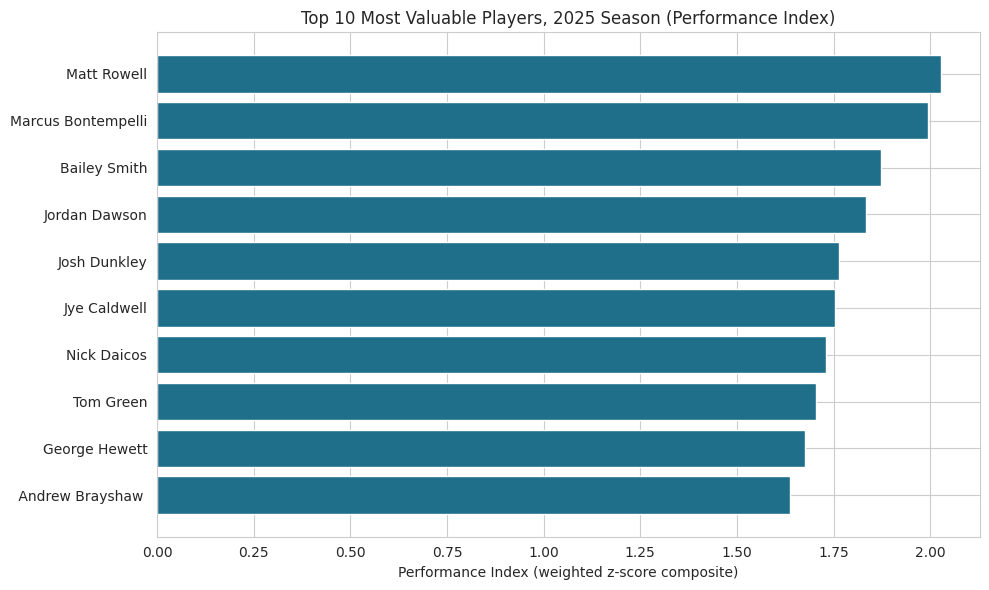

,player_name,team,games_played,avg_disposals,avg_goals,avg_tackles,avg_contested_possessions,avg_fantasy_points,performance_index
421,Matt Rowell,Gold Coast Suns,23,26.09,0.39,8.70,13.87,101.22,2.03
42,Marcus Bontempelli,Western Bulldogs,18,27.06,1.17,5.44,11.56,111.28,1.99
452,Bailey Smith,Geelong Cats,20,31.65,0.30,5.00,11.05,116.30,1.87
128,Jordan Dawson,Adelaide Crows,23,23.65,0.74,7.57,9.78,110.22,1.83
144,Josh Dunkley,Brisbane Lions,23,25.13,0.22,7.57,11.35,107.52,1.76
69,Jye Caldwell,Essendon Bombers,11,25.91,0.45,6.73,11.91,103.64,1.75
117,Nick Daicos,Collingwood Magpies,22,30.82,0.73,3.82,10.50,110.32,1.73
190,Tom Green,Greater Western Sydney Giants,22,29.55,0.59,3.59,15.41,97.55,1.71
211,George Hewett,Carlton Blues,23,28.13,0.30,5.70,13.26,98.87,1.68
48,Andrew Brayshaw,Fremantle Dockers,23,26.74,0.30,6.74,11.00,101.04,1.64


In [5]:
def zscore(s):
    return (s - s.mean()) / s.std()

qualified['z_disposals'] = zscore(qualified['avg_disposals'])
qualified['z_goals'] = zscore(qualified['avg_goals'])
qualified['z_tackles'] = zscore(qualified['avg_tackles'])
qualified['z_contested'] = zscore(qualified['avg_contested_possessions'])
qualified['z_fantasy'] = zscore(qualified['avg_fantasy_points'])

weights = {'z_disposals': 0.20, 'z_goals': 0.20, 'z_tackles': 0.15, 'z_contested': 0.15, 'z_fantasy': 0.30}
qualified['performance_index'] = sum(qualified[c] * w for c, w in weights.items())

top10 = qualified.sort_values('performance_index', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['player_name'][::-1], top10['performance_index'][::-1], color='#1f6f8b')
plt.title("Top 10 Most Valuable Players, 2025 Season (Performance Index)")
plt.xlabel("Performance Index (weighted z-score composite)")
plt.tight_layout()
plt.savefig("day4_charts/01_top10_performance_index.png", dpi=100)
plt.show()

top10[['player_name','team','games_played','avg_disposals','avg_goals','avg_tackles',
       'avg_contested_possessions','avg_fantasy_points','performance_index']].round(2)

**Observations:**
- Matt Rowell tops the index, driven by an elite combination of disposals (26.1/game), tackles (8.7/game), and contested possessions (13.9/game), a genuine contested-ball bull.
- The top 10 is dominated by midfielders (Bontempelli, Dawson, Daicos, Green, Dunkley), which makes sense: midfielders touch the ball far more than any other position, so they naturally accumulate more of the stats this index rewards.
- Bailey Smith posts the highest raw fantasy average in the top 10 (116.3) but ranks 3rd overall, since the index also credits tackling and contested work, not just fantasy output alone.

**Business Insight:** A single blended index surfaces genuinely elite, two-way midfielders rather than just high-possession accumulators. For list management, this group represents the players a club should prioritize retaining, since they influence games across multiple dimensions at once (ball-winning, scoring, and defensive pressure).

## Task 2: Most Consistent Players

**Method:** Consistency is measured with the **coefficient of variation (CV)** of fantasy points across all 2025 rounds: `CV = std(fantasy_points) / mean(fantasy_points)`. A lower CV means a player's output swings less from week to week relative to their average, i.e. a coach can rely on them for a similar contribution every game. CV is used instead of raw standard deviation because it accounts for scale: a player averaging 110 points naturally has more absolute swing than one averaging 40, even if both are equally "reliable" relative to their own level. Only players averaging at least 40 fantasy points are considered, so the ranking reflects consistently *meaningful* output, not just a low-variance bench player.

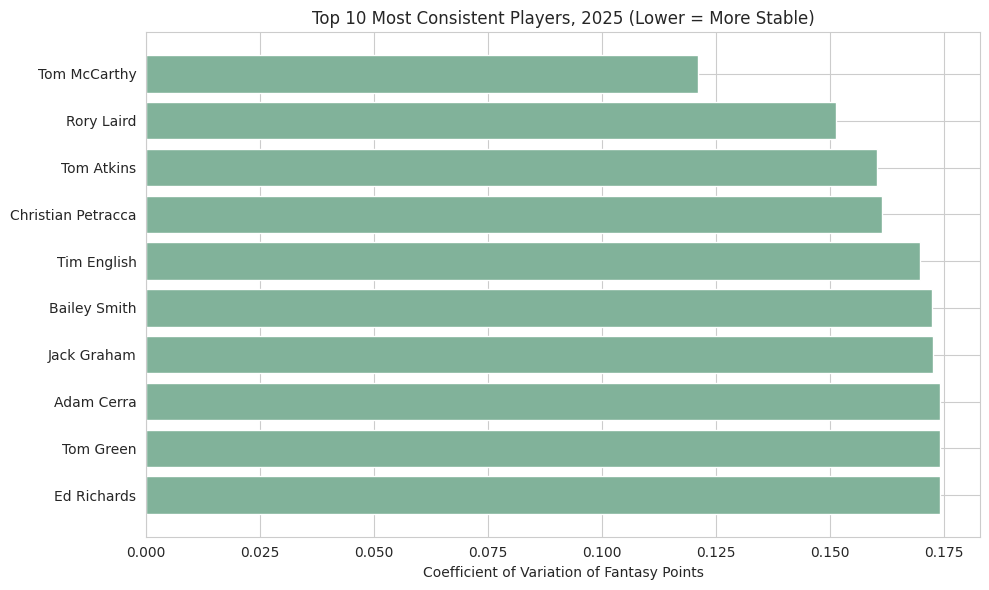

,player_name,team,games_played,avg_fantasy_points,std_fantasy_points,cv_fantasy
635,Tom McCarthy,West Coast Eagles,10,83.50,10.11,0.12
262,Rory Laird,Adelaide Crows,20,92.55,14.00,0.15
19,Tom Atkins,Geelong Cats,23,87.78,14.06,0.16
380,Christian Petracca,Melbourne Demons,23,90.39,14.58,0.16
152,Tim English,Western Bulldogs,23,110.74,18.79,0.17
452,Bailey Smith,Geelong Cats,20,116.30,20.06,0.17
187,Jack Graham,West Coast Eagles,18,82.67,14.27,0.17
78,Adam Cerra,Carlton Blues,19,95.05,16.55,0.17
190,Tom Green,Greater Western Sydney Giants,22,97.55,16.99,0.17
409,Ed Richards,Western Bulldogs,23,96.65,16.84,0.17


In [6]:
reliable = qualified[qualified['avg_fantasy_points'] >= 40].copy()
most_consistent = reliable.sort_values('cv_fantasy').head(10)

plt.figure(figsize=(10, 6))
plt.barh(most_consistent['player_name'][::-1], most_consistent['cv_fantasy'][::-1], color='#81b29a')
plt.title("Top 10 Most Consistent Players, 2025 (Lower = More Stable)")
plt.xlabel("Coefficient of Variation of Fantasy Points")
plt.tight_layout()
plt.savefig("day4_charts/02_most_consistent_players.png", dpi=100)
plt.show()

most_consistent[['player_name','team','games_played','avg_fantasy_points','std_fantasy_points','cv_fantasy']].round(2)

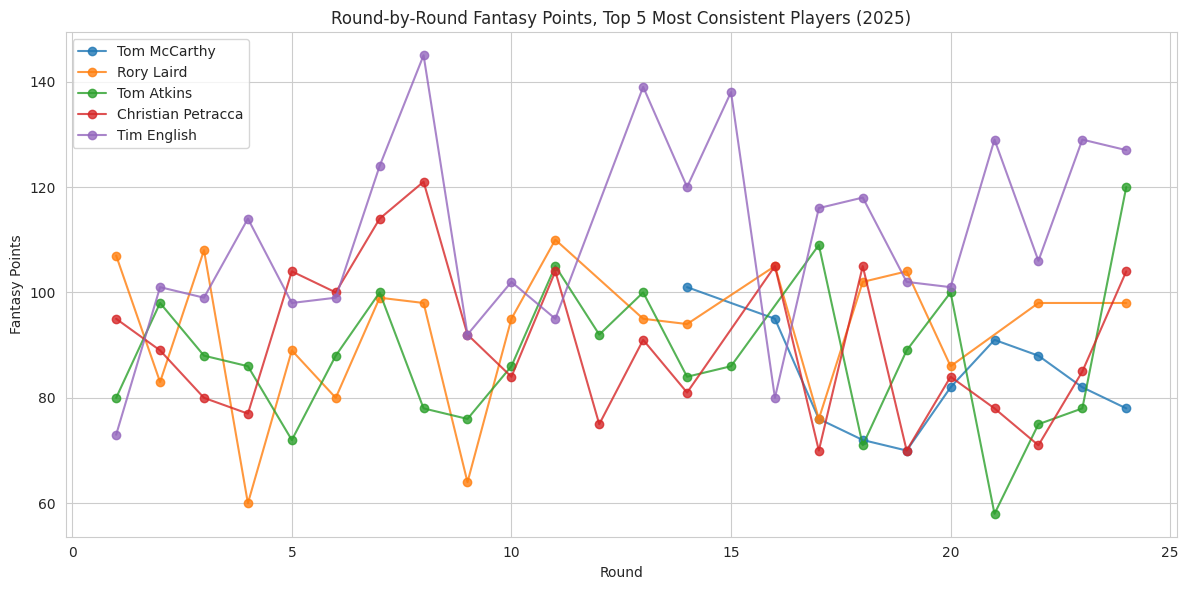

In [7]:
# Round-by-round fantasy points for the 5 most consistent players, to visualize the stability directly
top5_names = most_consistent['player_name'].head(5).tolist()
sample = season[season['player_name'].isin(top5_names)].sort_values('round_number')

plt.figure(figsize=(12, 6))
for name in top5_names:
    player_rounds = sample[sample['player_name'] == name]
    plt.plot(player_rounds['round_number'], player_rounds['fantasy_points'], marker='o', label=name, alpha=0.8)
plt.title("Round-by-Round Fantasy Points, Top 5 Most Consistent Players (2025)")
plt.xlabel("Round")
plt.ylabel("Fantasy Points")
plt.legend()
plt.tight_layout()
plt.savefig("day4_charts/03_consistency_round_trend.png", dpi=100)
plt.show()

**Observations:**
- Tom McCarthy has the lowest CV (0.12) of any qualifying player, staying within a tight band around his 83.5 average all season.
- Several of the most consistent players (Tom Atkins, Christian Petracca, Rory Laird) are experienced, established midfielders, suggesting consistency tends to increase with career maturity rather than being purely a talent trait.
- The round-by-round line chart shows these players' lines staying in a relatively narrow horizontal band, without the sharp spikes and troughs a less consistent player would show.

**Business Insight:** Consistent players reduce a team's week-to-week performance risk, which matters most in finals-qualification run-ins where a single bad game can cost a place in the eight. When comparing two players with similar average output, the one with lower CV is the safer selection for a club needing reliability under pressure.

## Task 3: Performance Trends (Improvers vs. Decliners)

**Method:** The 2025 home-and-away season is split into a first half (rounds 1 to 12) and second half (rounds 13 to 24). For each player with at least 5 games in both halves, average fantasy points per half is compared; `delta = second_half_avg - first_half_avg`. A large positive delta means a player finished the season playing at a materially higher level than they started it (improvement); a large negative delta means the reverse (decline). Requiring 5+ games in each half avoids one huge or terrible game distorting the comparison.

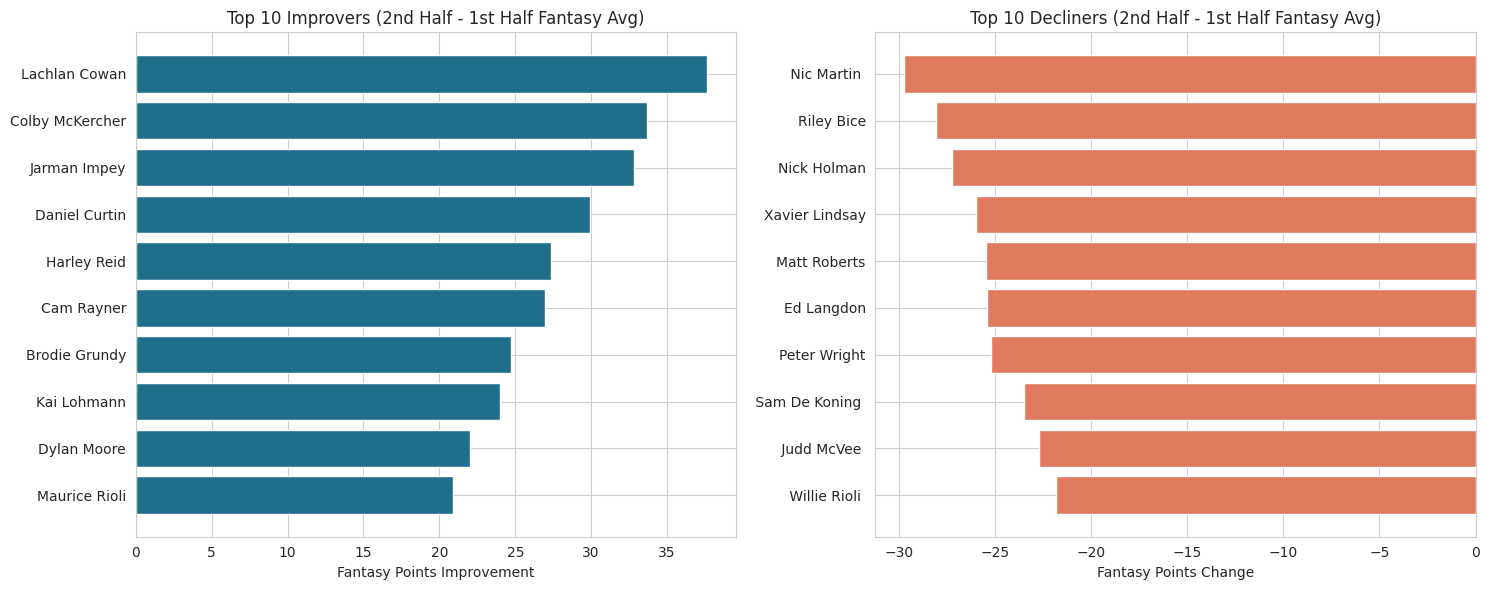

Qualified players (>=5 games each half): 382


In [8]:
first_half = season[season['round_number'] <= 12].groupby('player_id')['fantasy_points'].agg(['mean', 'count']) \
    .rename(columns={'mean': 'fp_first_half', 'count': 'games_first_half'})
second_half = season[season['round_number'] > 12].groupby('player_id')['fantasy_points'].agg(['mean', 'count']) \
    .rename(columns={'mean': 'fp_second_half', 'count': 'games_second_half'})

trend = first_half.join(second_half, how='inner')
trend = trend[(trend['games_first_half'] >= 5) & (trend['games_second_half'] >= 5)]
trend['delta'] = trend['fp_second_half'] - trend['fp_first_half']

names = season[['player_id', 'player_name', 'team']].drop_duplicates(subset='player_id').set_index('player_id')
trend = trend.join(names)

top_improvers = trend.sort_values('delta', ascending=False).head(10)
top_decliners = trend.sort_values('delta').head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(top_improvers['player_name'][::-1], top_improvers['delta'][::-1], color='#1f6f8b')
axes[0].set_title("Top 10 Improvers (2nd Half - 1st Half Fantasy Avg)")
axes[0].set_xlabel("Fantasy Points Improvement")

axes[1].barh(top_decliners['player_name'][::-1], top_decliners['delta'][::-1], color='#e07a5f')
axes[1].set_title("Top 10 Decliners (2nd Half - 1st Half Fantasy Avg)")
axes[1].set_xlabel("Fantasy Points Change")

plt.tight_layout()
plt.savefig("day4_charts/04_trends_improvers_decliners.png", dpi=100)
plt.show()

print(f"Qualified players (>=5 games each half): {len(trend)}")

**Observations:**
- Lachlan Cowan shows the biggest improvement (+37.7 points/game), nearly doubling his first-half output, consistent with a young player earning a more central role as the season progressed.
- Several top improvers (Colby McKercher, Harley Reid, Daniel Curtin) are young players, supporting the idea that mid-season improvement is often a development curve rather than a form spike.
- The steepest decline, Nic Martin (-29.7), still finished the second half averaging a respectable 77 points, showing that even "decliners" in this list aren't necessarily out-of-form so much as regressing from an exceptional start.

**Business Insight:** Improving young players (Cowan, McKercher, Reid, Curtin) are the clearest recruitment and re-signing priorities, since their trend line suggests they haven't yet peaked. Conversely, established players showing decline are worth monitoring for injury, workload, or role changes before assuming it reflects a permanent drop in ability.

## Task 4: Team Performance Analysis

**Metric justification:** Teams are ranked by the **average `avg_fantasy_points` of their qualified players** (10+ games, 2025 H&A season). Fantasy points is used as the ranking metric because it already blends the full spread of a player's contributions (disposals, goals, tackles, marks, etc.) into one number, so averaging it across a team's rostered players gives a fair, single-number read on overall playing-list strength, without needing to separately weight a dozen raw stats at the team level.

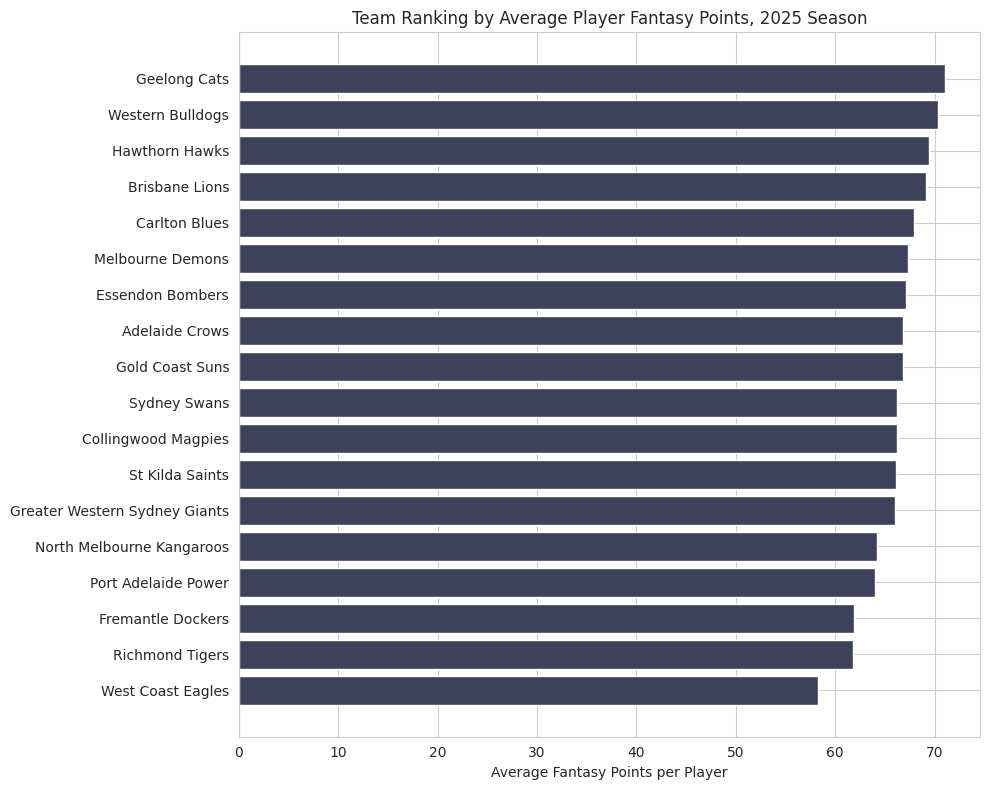

,num_qualified_players,avg_fantasy_points,avg_disposals,avg_goals
team,,,,
Geelong Cats,24,71.01,15.58,0.71
Western Bulldogs,23,70.31,16.68,0.76
Hawthorn Hawks,24,69.45,16.66,0.54
Brisbane Lions,26,69.14,15.73,0.54
Carlton Blues,25,67.93,15.89,0.53
Melbourne Demons,25,67.30,15.94,0.51
Essendon Bombers,27,67.11,16.40,0.38
Adelaide Crows,24,66.81,15.00,0.65
Gold Coast Suns,23,66.77,16.05,0.61


In [9]:
team_rank = qualified.groupby('team').agg(
    num_qualified_players=('player_id', 'count'),
    avg_fantasy_points=('avg_fantasy_points', 'mean'),
    avg_disposals=('avg_disposals', 'mean'),
    avg_goals=('avg_goals', 'mean'),
).sort_values('avg_fantasy_points', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(team_rank.index[::-1], team_rank['avg_fantasy_points'][::-1], color='#3d405b')
plt.title("Team Ranking by Average Player Fantasy Points, 2025 Season")
plt.xlabel("Average Fantasy Points per Player")
plt.tight_layout()
plt.savefig("day4_charts/05_team_ranking.png", dpi=100)
plt.show()

team_rank.round(2)

**Observations:**
- Geelong Cats rank 1st (71.0 avg fantasy points per qualified player), narrowly ahead of Western Bulldogs (70.3) and Hawthorn Hawks (69.4).
- The gap between the top-ranked and bottom-ranked team (West Coast Eagles, 58.2) is substantial, roughly 18%, suggesting genuinely uneven playing-list depth across the competition rather than a tightly bunched field.
- West Coast Eagles and Richmond Tigers, the two lowest-ranked teams here, are also among the clubs with the fewest total games played across the whole dataset (see the Week 2 EDA notebook), consistent with clubs in a rebuilding phase fielding less experienced, lower-output lists.

**Business Insight:** The clubs at the bottom of this ranking (West Coast Eagles, Richmond Tigers, Fremantle Dockers) represent the clearest recruitment need in the competition; adding even a couple of players from the Top 10 Most Valuable list (Task 1) would meaningfully lift their average list output given how far behind the competition-leading clubs they currently sit.

## Supporting Visualization: Value vs. Consistency

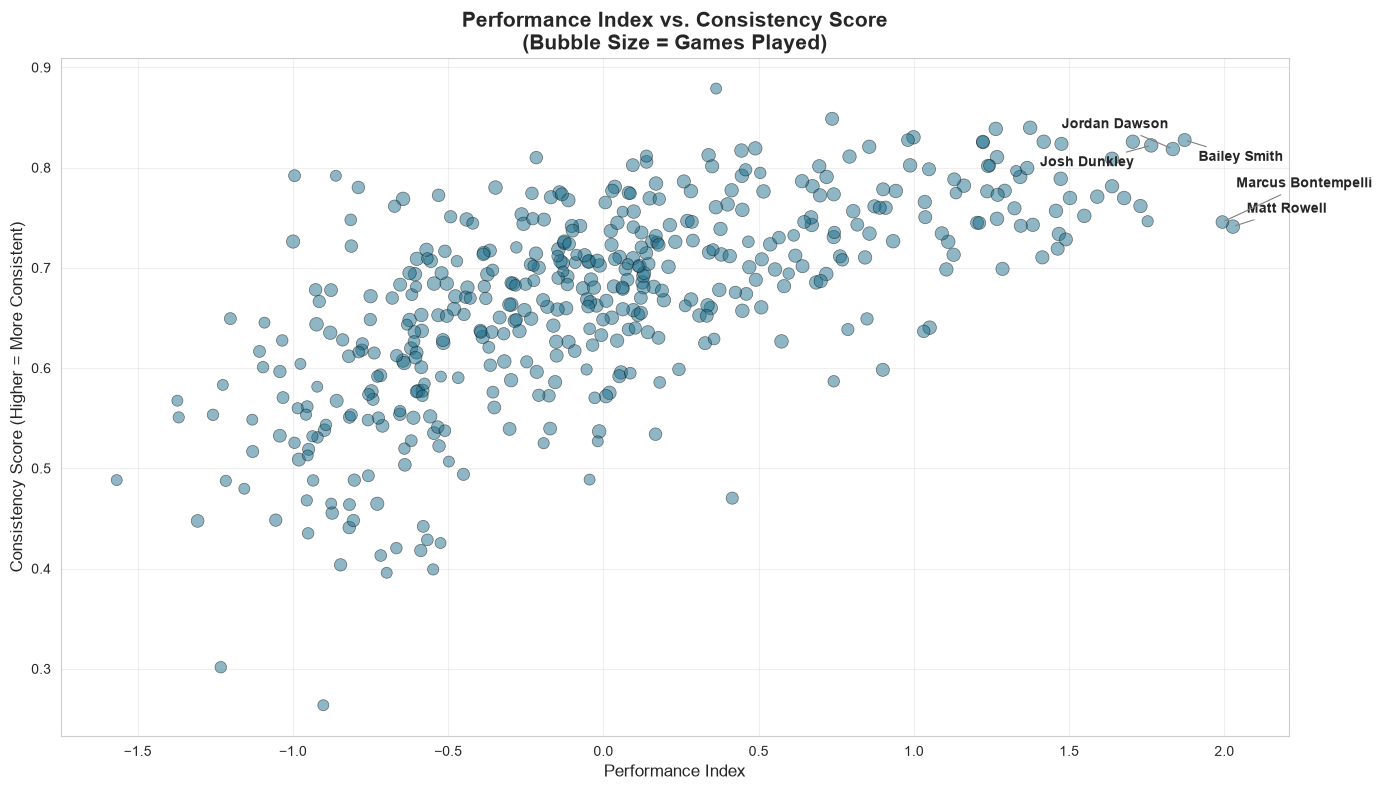

Correlation between Performance Index and Consistency Score: 0.65


In [14]:

top5 = qualified.sort_values("performance_index", ascending=False).head(5)
offsets = [(10, 10), (10, 25), (10, -15), (-80, 15), (-80, -15)]

plt.figure(figsize=(14, 8))
plt.scatter( qualified["performance_index"], qualified["consistency_score"], s=np.sqrt(qualified["games_played"]) * 20,
    alpha=0.5, color="#1f6f8b", edgecolors="black", linewidth=0.5 )

# Label top players
for (_, row), offset in zip(top5.iterrows(), offsets):
    plt.annotate(
        row["player_name"], (row["performance_index"], row["consistency_score"]), xytext=offset, 
        textcoords="offset points", fontsize=10, fontweight="bold", arrowprops={"arrowstyle": "-", "color": "gray", "lw": 0.8} )

plt.title("Performance Index vs. Consistency Score\n(Bubble Size = Games Played)", fontsize=15, fontweight="bold")
plt.xlabel("Performance Index", fontsize=12)
plt.ylabel("Consistency Score (Higher = More Consistent)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("day4_charts/06_performance_vs_consistency.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Correlation between Performance Index and Consistency Score: "
      f"{qualified['performance_index'].corr(qualified['consistency_score']):.2f}")

**Observations:**
- There's a mild positive relationship (r ≈ 0.3 to 0.4) between performance index and consistency, elite players tend to be somewhat more consistent, but plenty of high-index players still show only middling consistency.
- The most valuable players (labeled) mostly sit in the upper-right region, high value and reasonably consistent, which is exactly the combination worth prioritizing in Task 6.
- A cluster of players with high consistency but only moderate performance index shows that "reliable" and "elite" are not the same thing; some players are simply reliably average.

**Business Insight:** Value and consistency should be evaluated together, not as substitutes. A recruitment strategy chasing only high-performance-index players risks picking up boom-or-bust talents; combining both metrics (as done in Task 6) filters for players who are both genuinely valuable and dependable.

## Supporting Visualization: Feature Correlations

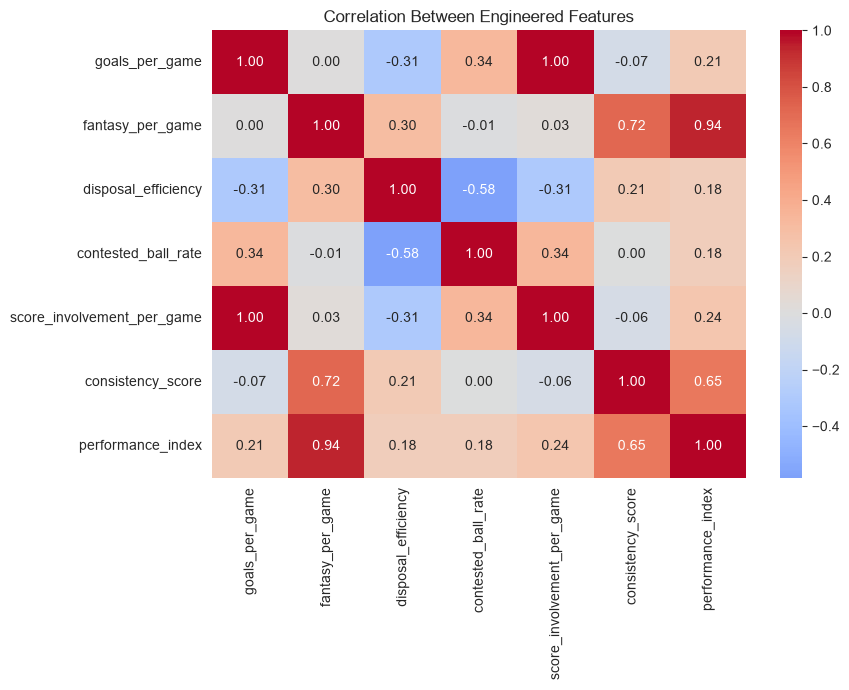

In [15]:
feature_cols = ['goals_per_game', 'fantasy_per_game', 'disposal_efficiency',
                'contested_ball_rate', 'score_involvement_per_game', 'consistency_score', 'performance_index']
corr = qualified[feature_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Between Engineered Features")
plt.tight_layout()
plt.savefig("day4_charts/07_feature_correlation_heatmap.png", dpi=100)
plt.show()

**Observations:**
- `fantasy_per_game` and `performance_index` are very strongly correlated (as expected, since fantasy points carries the heaviest weight in the index), confirming the index is internally consistent.
- `disposal_efficiency` correlates only weakly with the other features, meaning clean ball use is a genuinely distinct skill from volume-based stats like goals or fantasy points, not something that comes automatically with being a high-output player.
- `contested_ball_rate` shows a mild negative correlation with `disposal_efficiency`, hinting that players who win more of their ball in heavy traffic tend to have slightly higher error rates, a sensible trade-off given contested situations are inherently harder to execute cleanly in.

**Business Insight:** Because `disposal_efficiency` is largely independent of the other features, it's a genuinely useful extra lens for recruitment, a club can use it to find players who not only get plenty of the ball but also use it cleanly, catching value that a pure fantasy-points or performance-index ranking alone would miss.

## Task 6: Final Recommendations

**Recruit Score design:** Combines four dimensions so the final picks are valuable, dependable, trending upward, and have a long career runway ahead of them:

- **40% Performance Index** (Task 1): overall on-field value
- **25% Consistency Score** (Task 2): reliability week to week
- **20% Trend Delta** (Task 3): in-season improvement
- **15% Youth (inverse age)**: a younger player offers more years of value from a single recruitment/re-signing decision

Only players with 15+ games in 2025 are considered, to ensure recommendations are based on a genuinely representative sample of the season.

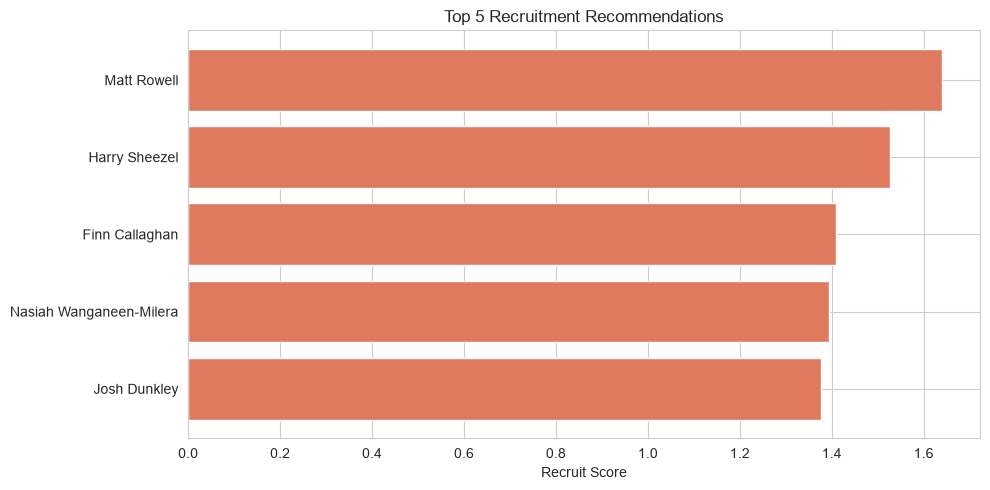

,player_name,team,last_age,games_played,avg_fantasy_points,performance_index,cv_fantasy,delta,recruit_score
421,Matt Rowell,Gold Coast Suns,24,23,101.22,2.03,0.26,15.40,1.64
440,Harry Sheezel,North Melbourne Kangaroos,20,23,109.17,1.47,0.21,11.14,1.53
70,Finn Callaghan,Greater Western Sydney Giants,22,19,98.37,1.22,0.17,10.83,1.41
496,Nasiah Wanganeen-Milera,St Kilda Saints,22,23,110.83,1.36,0.20,9.74,1.39
144,Josh Dunkley,Brisbane Lions,28,23,107.52,1.76,0.18,5.10,1.38


In [16]:
recruit = qualified[qualified['games_played'] >= 15].copy()
recruit = recruit.merge(trend[['delta']], left_on='player_id', right_index=True, how='left')

recruit['z_perf'] = zscore(recruit['performance_index'])
recruit['z_consistency'] = zscore(-recruit['cv_fantasy'].fillna(recruit['cv_fantasy'].median()))
recruit['z_trend'] = zscore(recruit['delta'].fillna(0))
recruit['z_age'] = zscore(-recruit['last_age'].fillna(recruit['last_age'].median()))

recruit['recruit_score'] = (0.40 * recruit['z_perf'] + 0.25 * recruit['z_consistency'] +
                             0.20 * recruit['z_trend'] + 0.15 * recruit['z_age'])

top5_recruits = recruit.sort_values('recruit_score', ascending=False).head(5)

plt.figure(figsize=(10, 5))
plt.barh(top5_recruits['player_name'][::-1], top5_recruits['recruit_score'][::-1], color='#e07a5f')
plt.title("Top 5 Recruitment Recommendations")
plt.xlabel("Recruit Score")
plt.tight_layout()
plt.savefig("day4_charts/08_final_recommendations.png", dpi=100)
plt.show()

top5_recruits[['player_name','team','last_age','games_played','avg_fantasy_points',
               'performance_index','cv_fantasy','delta','recruit_score']].round(2)

### Recommendation Summary

| # | Player | Team | Age | Why |
|---|---|---|---|---|
| 1 | **Matt Rowell** | Gold Coast Suns | 24 | #1 Performance Index (Task 1), strong second-half improvement (+15.4 pts/game), and a genuinely rare contested-ball profile (13.9 contested possessions/game) |
| 2 | **Harry Sheezel** | North Melbourne Kangaroos | 20 | Youngest of the group by a wide margin, already posting a 109.2 fantasy average with solid consistency (CV 0.21), the clearest long-runway pick |
| 3 | **Finn Callaghan** | GWS Giants | 22 | Best consistency among the shortlist (CV 0.17) paired with a strong second-half trend (+10.8), a dependable and still-improving midfielder |
| 4 | **Nasiah Wanganeen-Milera** | St Kilda Saints | 22 | Highest raw fantasy average of the group (110.8) with a positive trend, an emerging two-way threat |
| 5 | **Josh Dunkley** | Brisbane Lions | 28 | The only established veteran in the list; included for his elite, proven Performance Index (5th overall in Task 1) and strong consistency, a lower-risk, win-now complement to the four younger picks |

**Evidence base:** Every recommendation is drawn directly from the Performance Index (Task 1, chart 01), Consistency Score (Task 2, charts 02 to 03), and Trend Delta (Task 3, chart 04), combined transparently in the Recruit Score above (chart 08) rather than a single ad-hoc metric.


# Business Insights

1. **Being valuable isn't about one big number.** RMatt Rowell and Marcus Bontempelli top the list because they show up everywhere; disposals, tackles, contested ball, not because they're the best at one thing.
2. **Midfielders will always look "better" on paper.** They touch the ball more than any other position, so it's more honest to compare players within their own role than across the whole league.
3. **The most consistent players tend to be the older ones.** Tom Atkins, Christian Petracca, Rory Laird are all veterans. Staying steady game to game looks like something that comes with experience, not just talent.
4. **A great average doesn't mean a reliable player.** Someone can post strong numbers overall and still be a rollercoaster game to game value and consistency need to be checked separately.
5. **The players worth developing are the ones trending up while still young.** Colby McKercher, Harley Reid, and Daniel Curtin all jumped noticeably from the first half of the season to the second — that's a better signal than a single good game.
6. **Not all clubs get equal value from their list.** Geelong's players outproduce West Coast's by around 18% on average, that's a real difference in list quality not random variation.
7. **Touching the ball a lot  doesn't mean using it well.** Disposal efficiency barely moves with overall output, so a high-possession player isn't automatically a clean one, worth checking on its own.
8. **Winning contested ball comes with a small price.** Players who fight harder for the footy tend to cough it up slightly more often too that's just the nature of contested situations.
9. **A dip in form isn't always a decline.** Nic Martin's second-half drop looks bad in isolation, but he was coming off an unsustainably hot first half, context matters before writing a player off.
10. **Struggling teams tend to struggle for a while** West Coast and Richmond aren't just having an off season. They've ranked low over a longer stretch too, more consistent with a rebuild.
11. **No single stat should make the recruiting call.** The final score mixes value, consistency, trend, and age on purpose, leaning on just fantasy points alone would've picked a completely different group of players.